In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [4]:
CAMELS_ROOT = Path("./camels")

# Define output directory for the processed files that our pipeline will use
OUTPUT_DIR = Path("./data_camels")
OUTPUT_DIR.mkdir(exist_ok=True)

# Define output file paths
BASIN_CHARS_OUT_PATH = OUTPUT_DIR / "basin_characteristics.csv"
DISCHARGE_OUT_PATH = OUTPUT_DIR / "usgs_discharge.csv"
# For backwards compatibility with the existing pipeline
RAINFALL_OUT_PATH = OUTPUT_DIR / "rainfall_series.csv"
# New file containing all forcings used in the GNN paper
ALL_FORCINGS_OUT_PATH = OUTPUT_DIR / "camels_forcings.csv"


# Define which meteorological forcing to use
FORCING_TYPE = "nldas"  # Options: "nldas", "daymet", "maurer"

# Define the base paths for forcing and observed flow data
FORCING_DIR = CAMELS_ROOT / "basin_timeseries_v1p2_metForcing_obsFlow/basin_dataset_public_v1p2/basin_mean_forcing" / FORCING_TYPE
FLOW_DIR = CAMELS_ROOT / "basin_timeseries_v1p2_metForcing_obsFlow/basin_dataset_public_v1p2/usgs_streamflow"

# --- Define Attributes and Forcings from the GNN Paper ---
# List of 27 static attributes identified from the GNN paper's Figure 6 
STATIC_ATTRIBUTES = [
    'p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 'high_prec_freq', 
    'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'elev_mean', 'slope_mean', 
    'area_gages2', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 
    'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 
    'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 
    'geol_permeability', 'carbonate_rocks_frac'
]

# List of 5 dynamic forcing variables used in the paper 
DYNAMIC_FORCINGS_COLS = ['prcp(mm/day)', 'srad(W/m2)', 'tmax(C)', 'tmin(C)', 'vp(Pa)']


In [5]:
print("Loading, consolidating, and filtering catchment attributes...")

# List of attribute text files
attribute_files = {
    "clim": "camels_clim.txt", "geol": "camels_geol.txt", "hydro": "camels_hydro.txt",
    "name": "camels_name.txt", "soil": "camels_soil.txt", "topo": "camels_topo.txt",
    "vege": "camels_vege.txt",
}

# Read each attribute file into a pandas DataFrame
dfs = []
for key, filename in attribute_files.items():
    file_path = CAMELS_ROOT / filename
    df = pd.read_csv(file_path, sep=';', header=0, dtype={'gauge_id': str})
    df.set_index('gauge_id', inplace=True)
    dfs.append(df)

# Concatenate all attribute DataFrames
basin_characteristics_full_df = pd.concat(dfs, axis=1)
basin_characteristics_full_df.columns = [col.strip().lower() for col in basin_characteristics_full_df.columns]
basin_characteristics_full_df.index.name = 'site_no'
basin_characteristics_full_df.rename(columns={'gauge_lat': 'original_lat', 'gauge_lon': 'original_lon'}, inplace=True)
basin_characteristics_full_df['huc_02'] = basin_characteristics_full_df['huc_02'].astype(int).astype(str).str.zfill(2)

# --- Filter for the 27 attributes used in the GNN paper ---
# Also keep essential identifier/location columns
required_cols = ['huc_02', 'original_lat', 'original_lon']
final_static_cols = required_cols + STATIC_ATTRIBUTES
basin_characteristics_filtered_df = basin_characteristics_full_df[final_static_cols]

# Save the filtered basin characteristics to a CSV file
# basin_characteristics_filtered_df.to_csv(BASIN_CHARS_OUT_PATH)

print(f"Successfully created filtered basin characteristics file at: {BASIN_CHARS_OUT_PATH}")
print(f"Number of static attributes: {len(STATIC_ATTRIBUTES)}")
print("Sample of filtered basin characteristics:")
print(basin_characteristics_filtered_df.head())

print("\n--- Applying Site Filters from GNN Paper ---")
initial_site_count = len(basin_characteristics_full_df)

# Filter 1: Area must be <= 2000 km^2
# basin_characteristics_full_df = basin_characteristics_full_df[basin_characteristics_full_df['area_gages2'] <= 2000]
# print(f"Sites remaining after area filter (< 2000 km^2): {len(basin_characteristics_full_df)}")

# Filter 2: Area discrepancy must be low (< 10%)
# Calculate relative area error
# basin_characteristics_full_df['area_discrepancy'] = (
#     np.abs(basin_characteristics_full_df['area_gages2'] - basin_characteristics_full_df['area_geospa_fabric']) / basin_characteristics_full_df['area_gages2']
# )
# Keep sites where discrepancy is less than 10%
# basin_characteristics_full_df = basin_characteristics_full_df[basin_characteristics_full_df['area_discrepancy'] < 0.15].copy()
print(f"Sites remaining after area discrepancy filter (< 10%): {len(basin_characteristics_full_df)}")

# --- Filter the attribute list for the final dataset ---
required_cols = ['huc_02', 'original_lat', 'original_lon']
final_static_cols = required_cols + STATIC_ATTRIBUTES

# Ensure all required columns exist before trying to select them
cols_to_select = [col for col in final_static_cols if col in basin_characteristics_full_df.columns]
basin_characteristics_final_df = basin_characteristics_full_df[cols_to_select]

# Save the filtered basin characteristics to a CSV file
basin_characteristics_final_df.to_csv(BASIN_CHARS_OUT_PATH)

print(f"\nFiltered from {initial_site_count} to {len(basin_characteristics_final_df)} sites.")
print(f"Successfully created filtered basin characteristics file at: {BASIN_CHARS_OUT_PATH}")



Loading, consolidating, and filtering catchment attributes...
Successfully created filtered basin characteristics file at: data_camels/basin_characteristics.csv
Number of static attributes: 27
Sample of filtered basin characteristics:
         huc_02  original_lat  original_lon    p_mean  pet_mean   aridity  \
site_no                                                                     
01013500     01      47.23739     -68.58264  3.126679  1.971555  0.630559   
01022500     01      44.60797     -67.93524  3.608126  2.119256  0.587356   
01030500     01      45.50097     -68.30596  3.274405  2.043594  0.624111   
01031500     01      45.17501     -69.31470  3.522957  2.071324  0.587950   
01047000     01      44.86920     -69.95510  3.323146  2.090024  0.628929   

          p_seasonality  frac_snow  high_prec_freq  high_prec_dur  ...  \
site_no                                                            ...   
01013500       0.187940   0.313440           12.95       1.348958  ...   
010

In [4]:
print("\nProcessing time-series data for discharge and all 5 forcings...")

# Use the list of gauges from the attributes file as the master list
gauge_ids = basin_characteristics_final_df.index.tolist()
huc_02_list = basin_characteristics_final_df['huc_02'].tolist()

all_discharge_data = []
all_forcing_data = []
valid_gauges = []

# Loop through each catchment
for gauge_id, huc_02 in zip(gauge_ids, huc_02_list):
    try:
        # Define paths for the forcing and flow files
        forcing_file_path = FORCING_DIR / huc_02 / f"{gauge_id}_lump_cida_forcing_leap.txt"
        
        # *** CHANGE 1: Corrected the filename for streamflow ***
        flow_file_path = FLOW_DIR / huc_02 / f"{gauge_id}_streamflow_qc.txt"
        
        # Check if both files exist before processing
        if not os.path.exists(forcing_file_path):
            print(f"Warning: Forcing file not found for gauge {gauge_id}. Skipping.")
            continue
        if not os.path.exists(flow_file_path):
            print(f"Warning: Streamflow file not found for gauge {gauge_id}. Skipping.")
            continue

        # --- a) Process Forcing Data ---
        df_forcing_raw = pd.read_csv(forcing_file_path, sep=r'\s+', header=3)
        df_forcing_raw.columns = ['year', 'mnth', 'day', 'hr', 'dayl_s', 'prcp(mm/day)', 'srad(W/m2)', 'swe(mm)', 'tmax(C)', 'tmin(C)', 'vp(Pa)']
        df_forcing_raw['dateTime'] = pd.to_datetime(df_forcing_raw[['year', 'mnth', 'day']].rename(columns={'mnth': 'month'}))
        df_forcing_raw.replace([-999.0, -999.00], 0, inplace=True)

        df_forcing = df_forcing_raw[['dateTime'] + DYNAMIC_FORCINGS_COLS].set_index('dateTime')
        df_forcing.columns = pd.MultiIndex.from_product([[gauge_id], df_forcing.columns])
        all_forcing_data.append(df_forcing)

        # --- b) Process Observed Flow Data (Discharge) ---
        # *** CHANGE 2: Updated column names to match file structure ***
        df_flow = pd.read_csv(flow_file_path, sep=r'\s+', header=None, names=['gauge_id_text', 'year', 'month', 'day', 'flow_cfs', 'qc_flag'])
        df_flow['dateTime'] = pd.to_datetime(df_flow[['year', 'month', 'day']])
        df_flow.replace([-999.0, -999.00], 0, inplace=True)

        df_discharge = df_flow[['dateTime', 'flow_cfs']].rename(columns={'flow_cfs': 'value'})
        df_discharge['siteCode'] = gauge_id
        all_discharge_data.append(df_discharge)
        
        # Add gauge to list of valid gauges
        valid_gauges.append(gauge_id)
        
    except Exception as e:
        print(f"An unexpected error occurred while processing {gauge_id}: {e}")
        continue
        


Processing time-series data for discharge and all 5 forcings...


In [5]:
if all_discharge_data:
    discharge_final_df = pd.concat(all_discharge_data, ignore_index=True)
    discharge_final_df.to_csv(DISCHARGE_OUT_PATH, index=False)
    print(f"\nSuccessfully created discharge time-series file at: {DISCHARGE_OUT_PATH}")
    print(discharge_final_df.head())
else:
    print("\nNo discharge data was processed.")


# In[6]:
# Consolidate and save all Forcing Data
if all_forcing_data:
    # --- Create file with all 5 forcings ---
    forcing_final_df = pd.concat(all_forcing_data, axis=1)
    forcing_final_df.sort_index(inplace=True)
    forcing_final_df.to_csv(ALL_FORCINGS_OUT_PATH)
    print(f"\nSuccessfully created full forcing data file at: {ALL_FORCINGS_OUT_PATH}")
    print(forcing_final_df.head())
    
    # --- Create single rainfall file for pipeline compatibility ---
    # This extracts just the precipitation column for each site
    rainfall_final_df = forcing_final_df.xs('prcp(mm/day)', level=1, axis=1)
    rainfall_final_df.to_csv(RAINFALL_OUT_PATH)
    print(f"\nSuccessfully created rainfall-only file for pipeline compatibility at: {RAINFALL_OUT_PATH}")
    print(rainfall_final_df.head())

else:
    print("\nNo forcing data was processed.")


Successfully created discharge time-series file at: data_camels/usgs_discharge.csv
    dateTime  value  siteCode
0 1980-01-01  655.0  01013500
1 1980-01-02  640.0  01013500
2 1980-01-03  625.0  01013500
3 1980-01-04  620.0  01013500
4 1980-01-05  605.0  01013500

Successfully created full forcing data file at: data_camels/camels_forcings.csv
               01013500                                        01022500  \
           prcp(mm/day) srad(W/m2) tmax(C) tmin(C)  vp(Pa) prcp(mm/day)   
dateTime                                                                  
1980-01-01          0.0     153.40   -6.54  -16.30  171.69          0.0   
1980-01-02          0.0     145.27   -6.18  -15.22  185.94          0.0   
1980-01-03          0.0     146.96   -9.89  -18.86  138.39          0.0   
1980-01-04          0.0     146.20  -10.98  -19.76  120.06          0.0   
1980-01-05          0.0     170.43  -11.29  -22.21  117.87          0.0   

                                               ...    

In [6]:
sns.set_theme(style="whitegrid")

DATA_DIR = Path("./data_camels")
BASIN_CHARS_PATH = DATA_DIR / "basin_characteristics.csv"
DISCHARGE_PATH = DATA_DIR / "usgs_discharge.csv"
RAINFALL_PATH = DATA_DIR / "rainfall_series.csv"
# Load the new all_forcings file
ALL_FORCINGS_PATH = DATA_DIR / "camels_forcings.csv"


try:
    basin_df = pd.read_csv(BASIN_CHARS_PATH, index_col='site_no')
    discharge_df = pd.read_csv(DISCHARGE_PATH, parse_dates=['dateTime'], dtype={'siteCode': str})
    rainfall_df = pd.read_csv(RAINFALL_PATH, index_col='dateTime', parse_dates=True)
    # Add the loading for the new file, with multi-level header
    forcings_df = pd.read_csv(ALL_FORCINGS_PATH, index_col=0, header=[0, 1], parse_dates=True)
    print("All data files loaded successfully.")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the data preparation notebook has been run successfully.")
    # Stop execution if files are not found
    basin_df, discharge_df, rainfall_df, forcings_df = None, None, None, None



All data files loaded successfully.


--- Basin Characteristics Analysis ---
Shape: (671, 30)

Sample Data:
         huc_02  original_lat  original_lon    p_mean  pet_mean   aridity  \
site_no                                                                     
1013500       1      47.23739     -68.58264  3.126679  1.971555  0.630559   
1022500       1      44.60797     -67.93524  3.608126  2.119256  0.587356   
1030500       1      45.50097     -68.30596  3.274405  2.043594  0.624111   
1031500       1      45.17501     -69.31470  3.522957  2.071324  0.587950   
1047000       1      44.86920     -69.95510  3.323146  2.090024  0.628929   

         p_seasonality  frac_snow  high_prec_freq  high_prec_dur  ...  \
site_no                                                           ...   
1013500       0.187940   0.313440           12.95       1.348958  ...   
1022500      -0.114530   0.245259           20.55       1.205279  ...   
1030500       0.047358   0.277018           17.15       1.207746  ...   
1031500       0.104091   

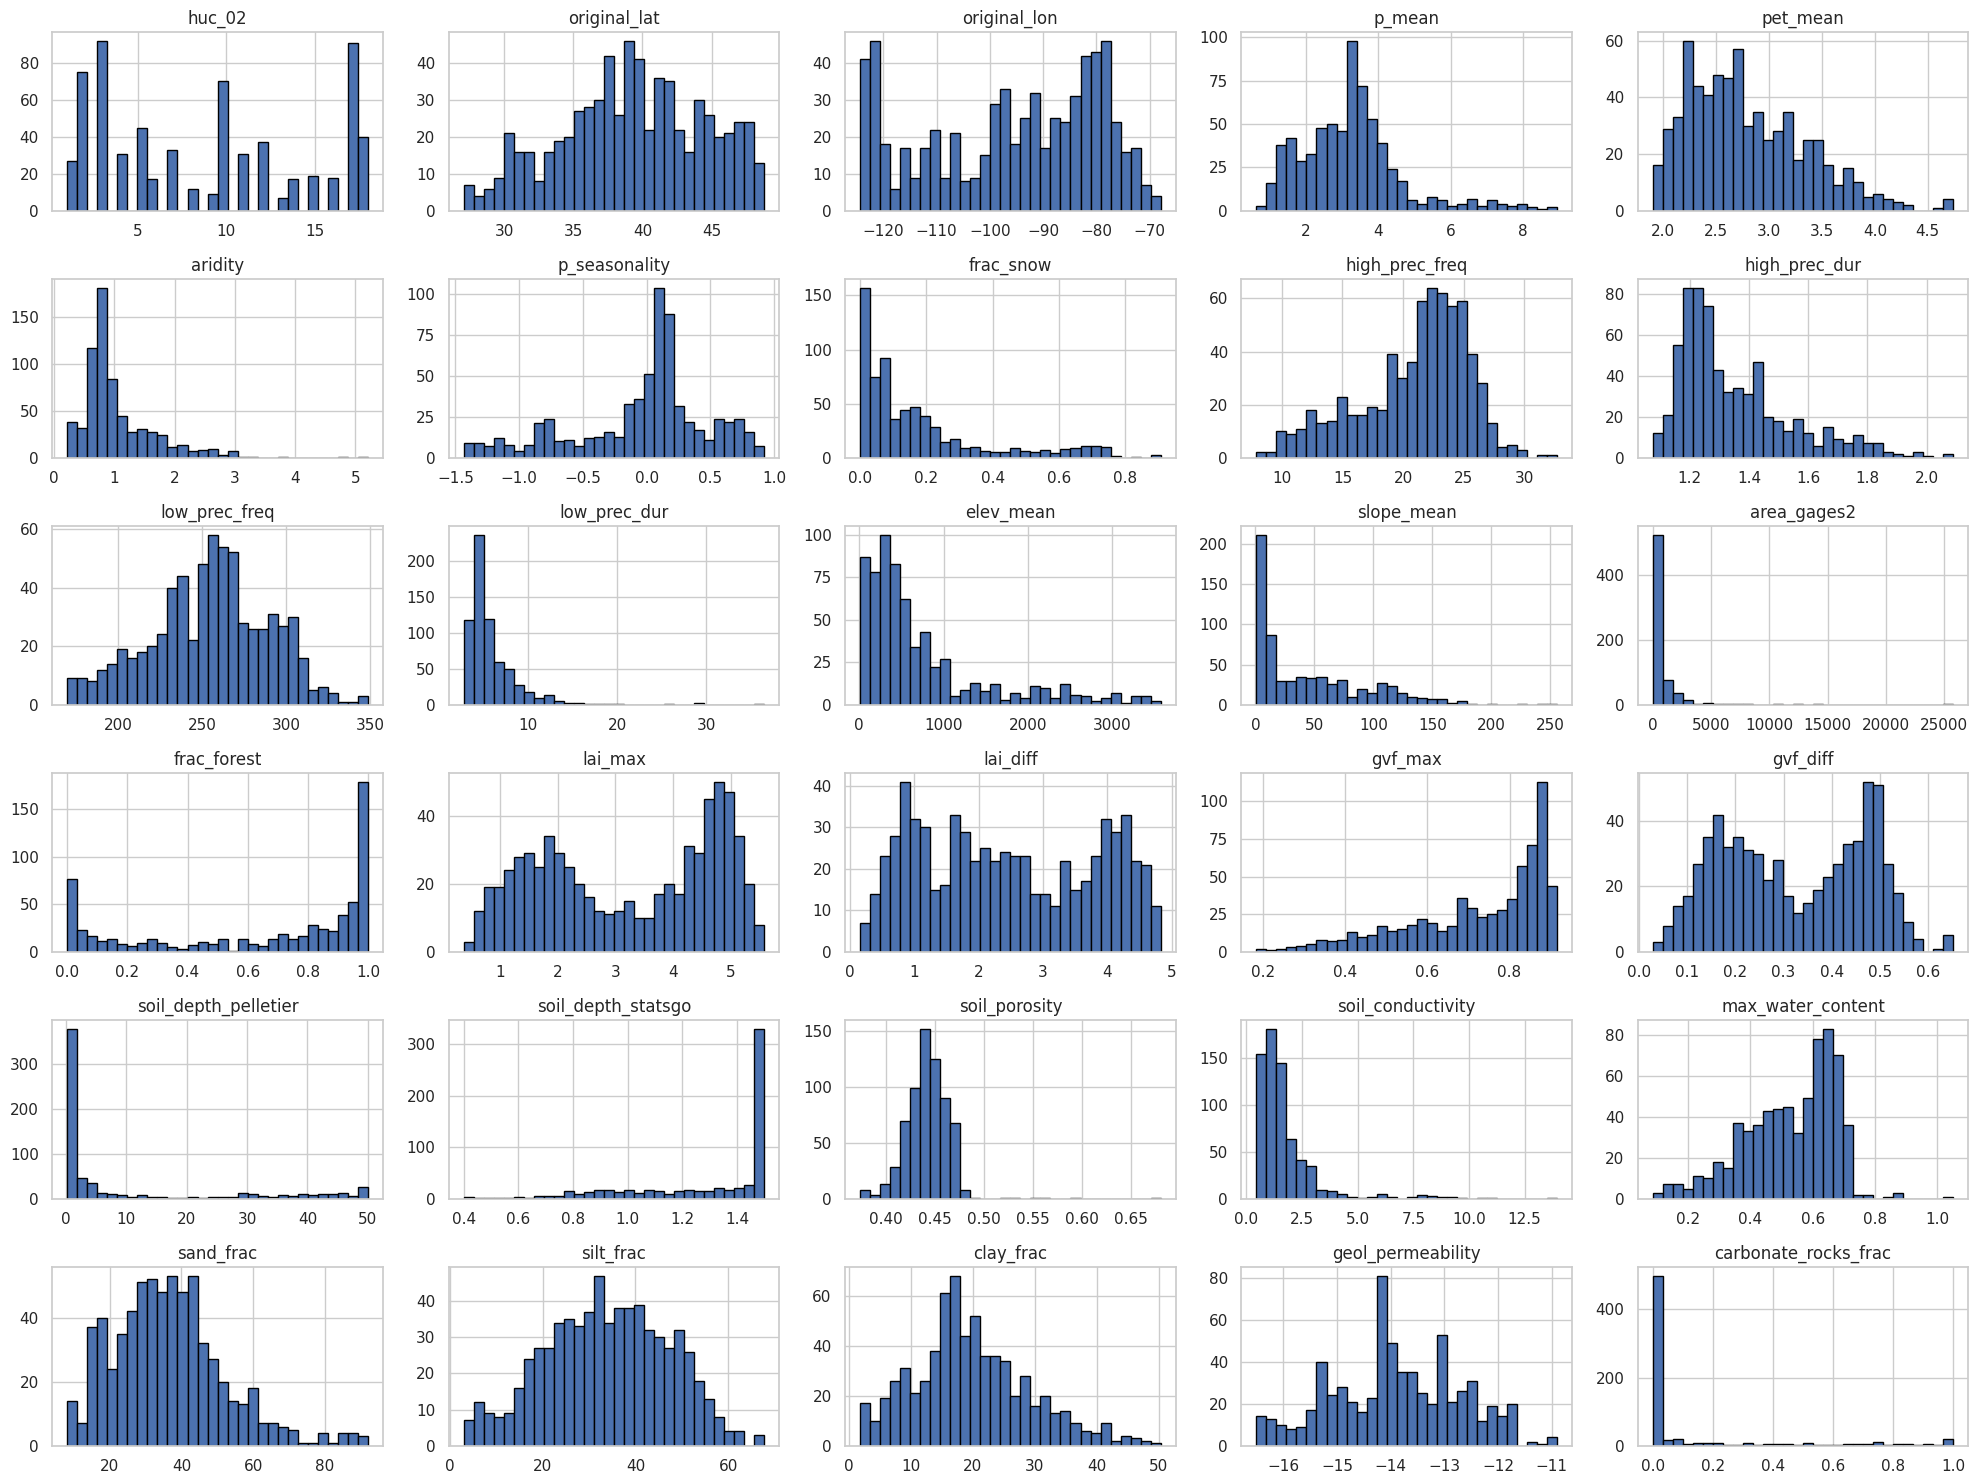

In [7]:
if basin_df is not None:
    print("--- Basin Characteristics Analysis ---")
    print(f"Shape: {basin_df.shape}")
    print("\nSample Data:")
    print(basin_df.head())

    print("\nMissing Data Check:")
    # Reports the number of missing values per attribute column
    missing_data_static = basin_df.isnull().sum()
    print(missing_data_static[missing_data_static > 0])
    if missing_data_static.sum() == 0:
        print("No missing values in static attributes. Great!")
        
    print("\nAttribute Distributions:")
    # Plot histograms for all numeric attributes to visualize their distributions
    basin_df.hist(figsize=(20, 15), bins=30, edgecolor='black')
    plt.tight_layout()
    plt.show()




--- Discharge Time Series Analysis ---
Shape: (8415489, 3)
Date Range: 1980-01-01 00:00:00 to 2014-12-31 00:00:00

Sample Data:
    dateTime  value  siteCode
0 1980-01-01  655.0  01013500
1 1980-01-02  640.0  01013500
2 1980-01-03  625.0  01013500
3 1980-01-04  620.0  01013500
4 1980-01-05  605.0  01013500

Missing Data Check:
dateTime    0
value       0
siteCode    0
dtype: int64



Pivoted discharge data shape: (12784, 671)


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/tmp/ipykernel_1518526/773025004.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Site Code', loc='upper right')


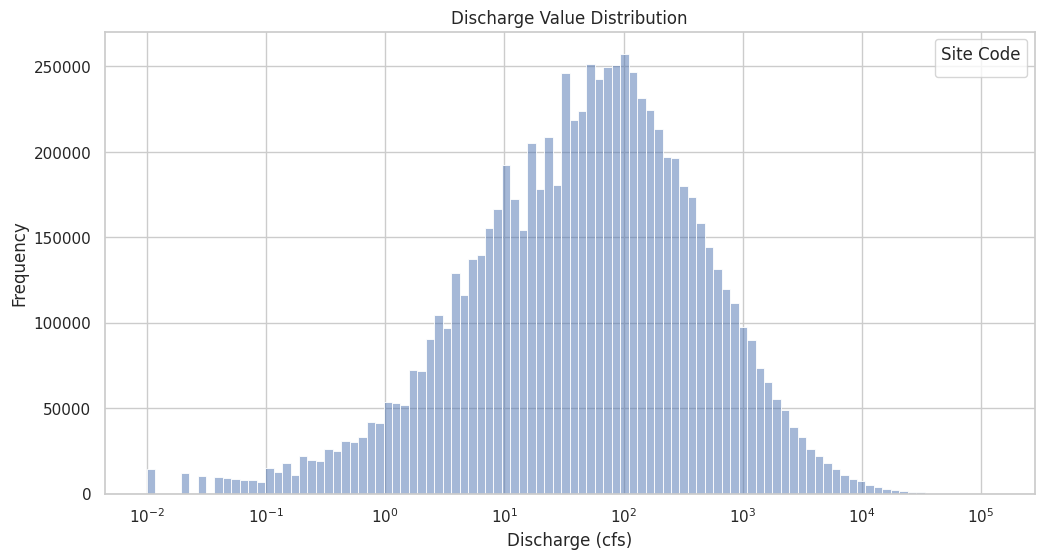

siteCode,01013500,01022500,01030500,01031500,01047000,01052500,01054200,01055000,01057000,01073000,...,14303200,14305500,14306340,14306500,14308990,14309500,14316700,14325000,14362250,14400000
count,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,12784.000000,...,11507.000000,12784.00000,11507.000000,12784.000000,10684.00000,12784.000000,12784.000000,12784.000000,11507.000000,12784.000000
mean,1534.152300,504.979662,2732.151596,627.470807,798.107087,364.928653,199.648780,225.374155,143.194930,21.159073,...,17.363167,1427.25219,24.984793,1387.414111,82.36739,234.027120,721.997497,762.959121,4.905776,2246.257901
std,1793.522226,590.754367,3451.625042,1055.287293,1256.882563,569.937108,386.253503,406.909496,231.316326,36.066221,...,26.111846,2116.31171,44.471462,2075.951060,162.28985,467.830626,1158.560249,1359.971586,13.292208,3802.232437
min,0.000000,0.000000,0.000000,0.000000,29.000000,9.200000,6.100000,2.900000,0.650000,0.000000,...,0.000000,42.00000,0.000000,56.000000,4.20000,2.100000,23.000000,7.200000,0.000000,28.000000
25%,474.000000,153.000000,592.000000,128.000000,200.000000,94.000000,45.000000,51.000000,34.000000,4.000000,...,2.500000,198.00000,2.000000,169.000000,12.00000,13.000000,76.000000,50.000000,0.560000,169.000000
50%,859.500000,311.000000,1400.000000,274.000000,364.000000,175.000000,88.000000,101.000000,72.000000,11.000000,...,8.900000,739.00000,9.400000,663.000000,31.00000,64.000000,329.000000,274.500000,1.500000,841.000000
75%,1810.000000,626.000000,3420.000000,674.000000,857.000000,381.000000,192.000000,226.000000,160.250000,25.000000,...,22.000000,1770.00000,29.000000,1700.000000,95.00000,248.000000,902.000000,909.000000,4.200000,2670.000000
max,17900.000000,6790.000000,25900.000000,31700.000000,36000.000000,9900.000000,8210.000000,9120.000000,6760.000000,942.000000,...,460.000000,36700.00000,870.000000,29400.000000,3980.00000,7180.000000,16700.000000,19400.000000,621.000000,57000.000000


In [8]:
if discharge_df is not None:
    print("\n--- Discharge Time Series Analysis ---")
    print(f"Shape: {discharge_df.shape}")
    print(f"Date Range: {discharge_df['dateTime'].min()} to {discharge_df['dateTime'].max()}")
    print("\nSample Data:")
    print(discharge_df.head())

    print("\nMissing Data Check:")
    print(discharge_df.isnull().sum())
    
    # Pivot the data for easier plotting and analysis later
    discharge_pivot = discharge_df.pivot(index='dateTime', columns='siteCode', values='value')
    print("\nPivoted discharge data shape:", discharge_pivot.shape)

# plot discharge value distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(discharge_pivot.values.flatten(), bins=100, kde=True, log_scale=True)
    plt.title("Discharge Value Distribution")
    plt.xlabel("Discharge (cfs)")
    plt.ylabel("Frequency")
    plt.legend(title='Site Code', loc='upper right')
    plt.show()      

discharge_pivot.describe()

In [9]:
if rainfall_df is not None:
    print("\n--- Rainfall Time Series Analysis ---")
    print(f"Shape: {rainfall_df.shape}")
    print(f"Date Range: {rainfall_df.index.min()} to {rainfall_df.index.max()}")
    print("\nSample Data:")
    print(rainfall_df.head())

    print("\nMissing Data Check:")
    missing_data_rain = rainfall_df.isnull().sum().sum()
    if missing_data_rain > 0:
        print(f"Total missing values in rainfall data: {missing_data_rain}")
    else:
        print("No missing values in rainfall data.")



--- Rainfall Time Series Analysis ---
Shape: (12784, 671)
Date Range: 1980-01-01 00:00:00 to 2014-12-31 00:00:00

Sample Data:
            01013500  01022500  01030500  01031500  01047000  01052500  \
dateTime                                                                 
1980-01-01       0.0       0.0       0.0       0.0       0.0       0.0   
1980-01-02       0.0       0.0       0.0       0.0       0.0       0.0   
1980-01-03       0.0       0.0       0.0       0.0       0.0       0.0   
1980-01-04       0.0       0.0       0.0       0.0       0.0       0.0   
1980-01-05       0.0       0.0       0.0       0.0       0.0       0.0   

            01054200  01055000  01057000  01073000  ...  14303200  14305500  \
dateTime                                            ...                       
1980-01-01       0.0       0.0       0.0       0.0  ...     38.06     32.74   
1980-01-02       0.0       0.0       0.0       0.0  ...     14.85      8.58   
1980-01-03       0.0       0.0       


--- All Forcings Time Series Analysis ---
Shape: (12784, 3355)
Date Range: 1980-01-01 00:00:00 to 2014-12-31 00:00:00

Sample Data:
               01013500                                        01022500  \
           prcp(mm/day) srad(W/m2) tmax(C) tmin(C)  vp(Pa) prcp(mm/day)   
dateTime                                                                  
1980-01-01          0.0     153.40   -6.54  -16.30  171.69          0.0   
1980-01-02          0.0     145.27   -6.18  -15.22  185.94          0.0   
1980-01-03          0.0     146.96   -9.89  -18.86  138.39          0.0   
1980-01-04          0.0     146.20  -10.98  -19.76  120.06          0.0   
1980-01-05          0.0     170.43  -11.29  -22.21  117.87          0.0   

                                               ...     14362250             \
           srad(W/m2) tmax(C) tmin(C)  vp(Pa)  ... prcp(mm/day) srad(W/m2)   
dateTime                                       ...                           
1980-01-01     178.46   -0.72  -

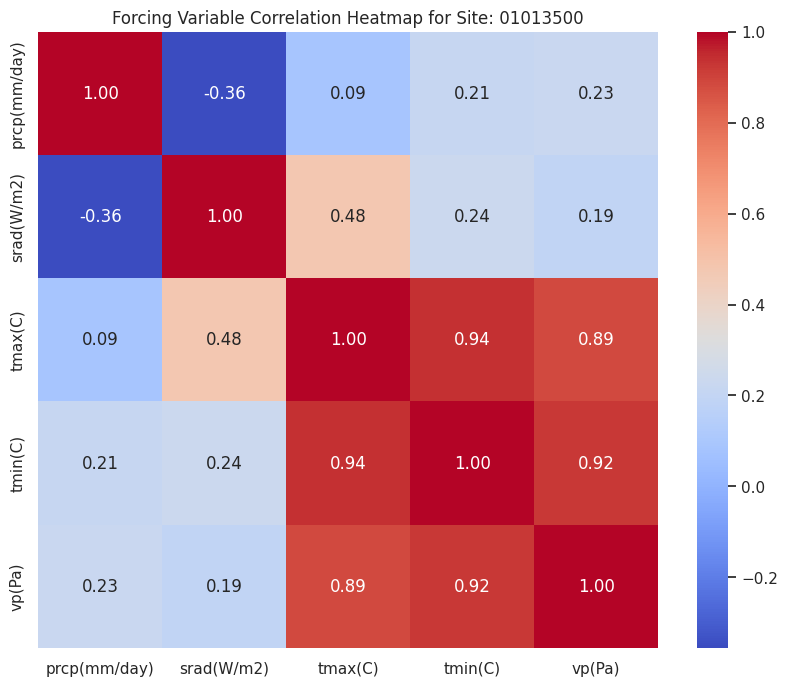

In [10]:

if forcings_df is not None:
    print("\n--- All Forcings Time Series Analysis ---")
    print(f"Shape: {forcings_df.shape}")
    print(f"Date Range: {forcings_df.index.min()} to {forcings_df.index.max()}")
    print("\nSample Data:")
    print(forcings_df.head())

    print("\nMissing Data Check:")
    missing_data_forcing = forcings_df.isnull().sum().sum()
    if missing_data_forcing > 0:
        print(f"Total missing values in forcing data: {missing_data_forcing}")
    else:
        print("No missing values in forcing data.")

    # Correlation heatmap for a single site's forcing variables
    sample_site = forcings_df.columns.levels[0][0]
    sample_forcing_site_df = forcings_df[sample_site]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(sample_forcing_site_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Forcing Variable Correlation Heatmap for Site: {sample_site}")
    plt.show()



--- Multi-Variable Analysis: Individual Forcings vs. Discharge ---
Plotting data for site 01013500 from 1985-06-01 to 1985-06-30


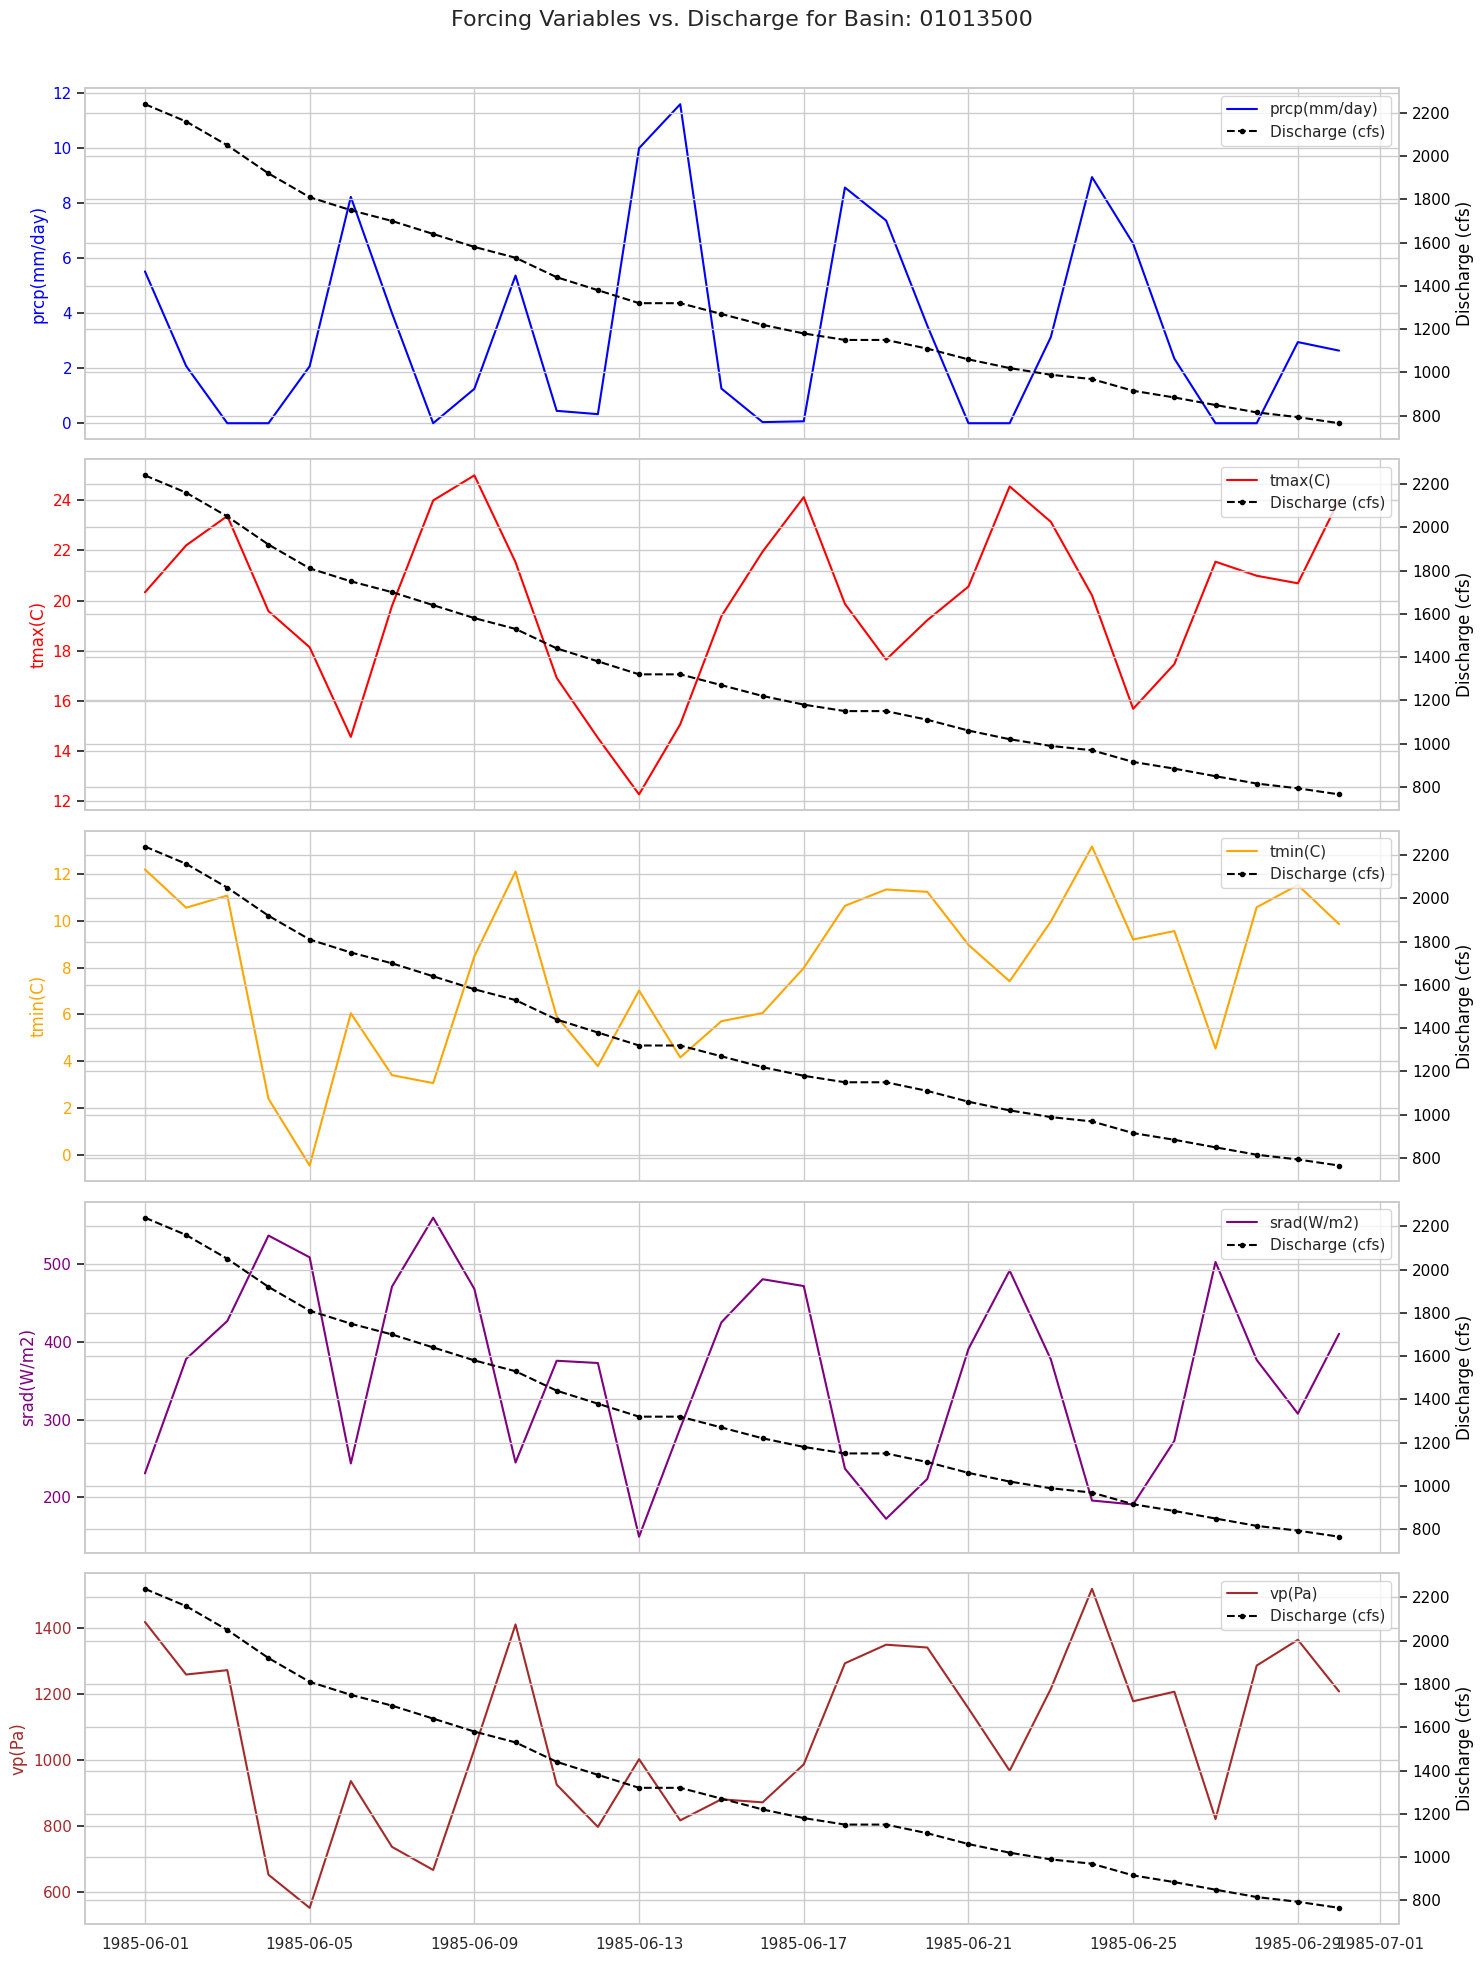

In [11]:
if discharge_df is not None and forcings_df is not None:
    print("\n--- Multi-Variable Analysis: Individual Forcings vs. Discharge ---")
    
    # Find the common sites between the forcings and discharge data
    common_sites = forcings_df.columns.get_level_values(0).intersection(discharge_pivot.columns)
    
    if not common_sites.empty:
        # Select the first common site as the sample
        sample_site = common_sites[0]
        start_date = '1985-06-01'
        end_date = '1985-06-30'
        
        print(f"Plotting data for site {sample_site} from {start_date} to {end_date}")

        # Prepare data for plotting
        sample_forcings = forcings_df.loc[start_date:end_date, sample_site]
        sample_discharge = discharge_pivot.loc[start_date:end_date, sample_site]

        # Define the forcing variables and their corresponding plot colors
        forcing_vars = {
            'prcp(mm/day)': 'blue',
            'tmax(C)': 'red',
            'tmin(C)': 'orange',
            'srad(W/m2)': 'purple',
            'vp(Pa)': 'brown'
        }

        # Create 5 subplots, one for each forcing variable vs. discharge
        fig, axes = plt.subplots(len(forcing_vars), 1, figsize=(15, 20), sharex=True)
        fig.suptitle(f'Forcing Variables vs. Discharge for Basin: {sample_site}', fontsize=16)

        for i, (var, color) in enumerate(forcing_vars.items()):
            ax = axes[i]
            ax_twin = ax.twinx()

            # Plot forcing variable on primary y-axis
            if var == 'p  rcp(mm/day)':
                # Use a bar plot for rainfall for better visualization
                ax.bar(sample_forcings.index, sample_forcings[var], color=color, alpha=0.6, label=var)
                ax.invert_yaxis() # Invert to have bars hang from the top
            else:
                ax.plot(sample_forcings.index, sample_forcings[var], color=color, label=var)
            
            ax.set_ylabel(var, color=color)
            ax.tick_params(axis='y', labelcolor=color)
            
            # Plot discharge on the secondary y-axis for every subplot
            ax_twin.plot(sample_discharge.index, sample_discharge, color='black', linestyle='--', marker='.', label='Discharge (cfs)')
            ax_twin.set_ylabel('Discharge (cfs)', color='black')
            ax_twin.tick_params(axis='y', labelcolor='black')
            
            # Create a combined legend for clarity
            lines, labels = ax.get_legend_handles_labels()
            lines2, labels2 = ax_twin.get_legend_handles_labels()
            ax_twin.legend(lines + lines2, labels + labels2, loc='upper right')

        plt.xlabel('Date')
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()
    else:
        print("Could not find any common sites between forcing data and discharge data to plot.")


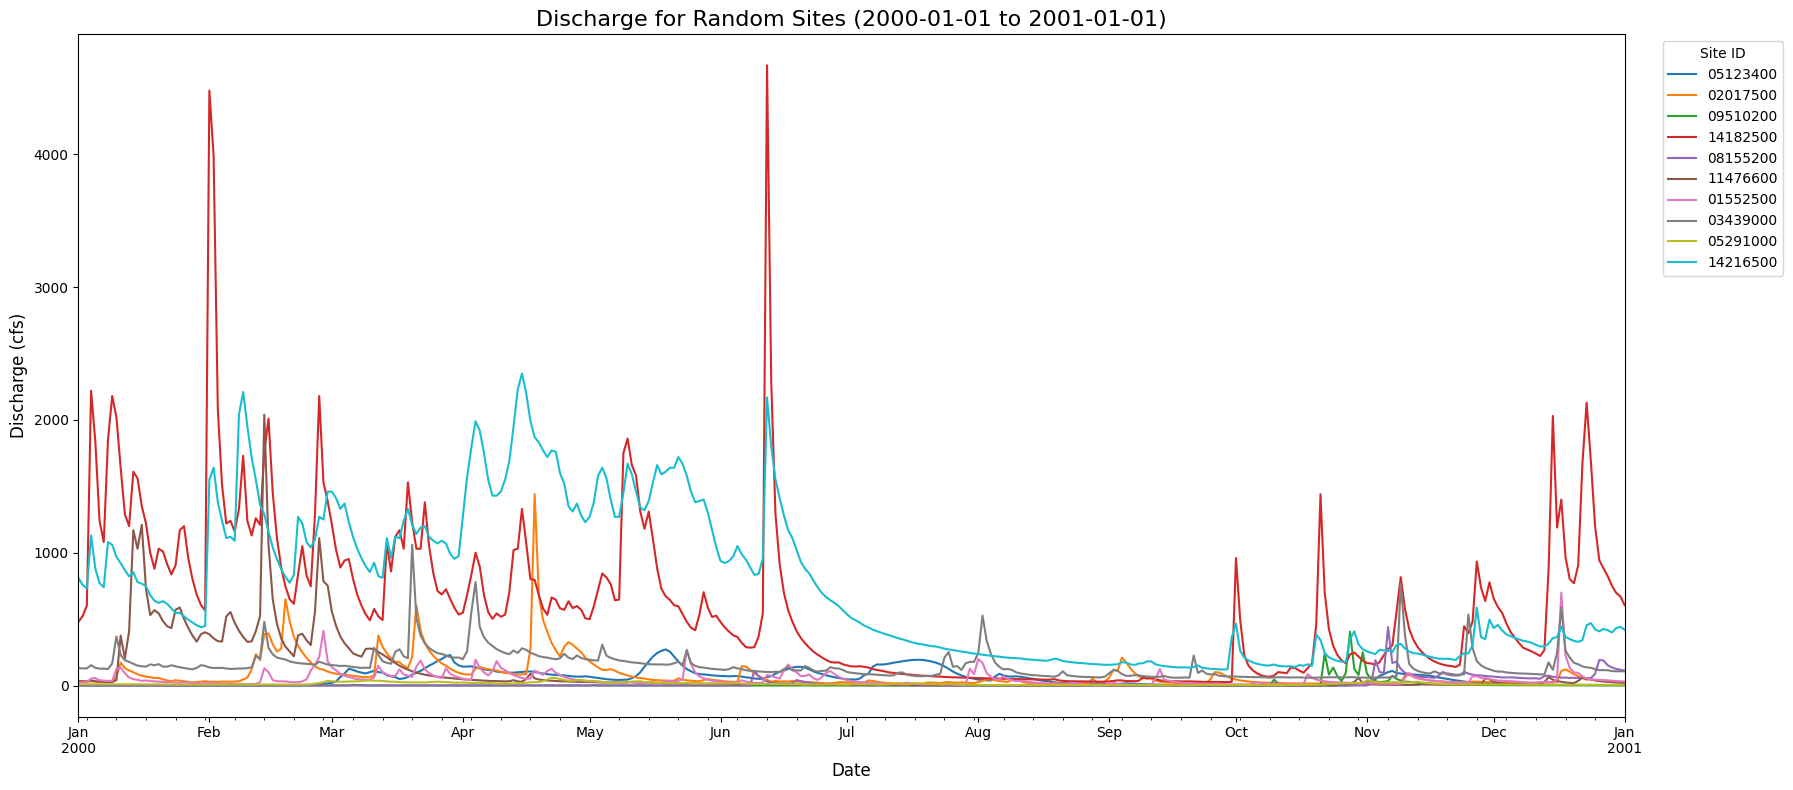

In [2]:
from sklearn.metrics import mutual_info_score
from tqdm.notebook import tqdm
import itertools

DATA_DIR = Path("./data_camels")
DISCHARGE_PATH = DATA_DIR / "usgs_discharge.csv"

discharge_df = pd.read_csv(DISCHARGE_PATH, parse_dates=['dateTime'], dtype={'siteCode': str})
discharge_pivot = discharge_df.pivot(index='dateTime', columns='siteCode', values='value')

num_sites_to_plot = 10
random_sites = random.sample(list(discharge_pivot.columns), num_sites_to_plot)
start_date = "2000-01-01"
end_date = "2001-01-01" # Using a 1-month period for better visualization

# Filter the data for the selected sites and time range
plot_data = discharge_pivot.loc[start_date:end_date, random_sites]


# --- Plot the Data ---
fig, ax = plt.subplots(figsize=(18, 8))

plot_data.plot(ax=ax, linestyle='-')

ax.set_title(f'Discharge for Random Sites ({start_date} to {end_date})', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (cfs)', fontsize=12)
ax.legend(title='Site ID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Discretizing data into 100 bins using quantiles...
Discretization complete.

Sample of discretized data:
siteCode    03050000  02202600  08200000  05466500  12167000  12377150  \
dateTime                                                                 
2001-01-01        51        82        47        17        62        20   
2001-01-02        50        80        46        17        48        18   
2001-01-03        49        77        46        18        49        18   
2001-01-04        48        74        46        19        70        18   
2001-01-05        47        70        45        20        98        18   

siteCode    03021350  12082500  02450250  11098000  ...  08086290  01583500  \
dateTime                                            ...                       
2001-01-01        49        32         6        36  ...         0        24   
2001-01-02        47        29         6        34  ...         0        23   
2001-01-03        43        31         4        36  ...     

  0%|          | 0/1225 [00:00<?, ?it/s]

Mutual information calculation complete.

Mutual Information Matrix (sample):
siteCode  03050000  02202600  08200000  05466500  12167000
siteCode                                                  
03050000  4.539484  3.039422  2.998374  3.228312  3.241135
02202600  3.039422  4.342897  2.797070  3.060596  3.059698
08200000  2.998374  2.797070  4.281982  2.999681  3.013934
05466500  3.228312  3.060596  2.999681  4.548366  3.250017
12167000  3.241135  3.059698  3.013934  3.250017  4.566407

Visualizing the results as a heatmap...


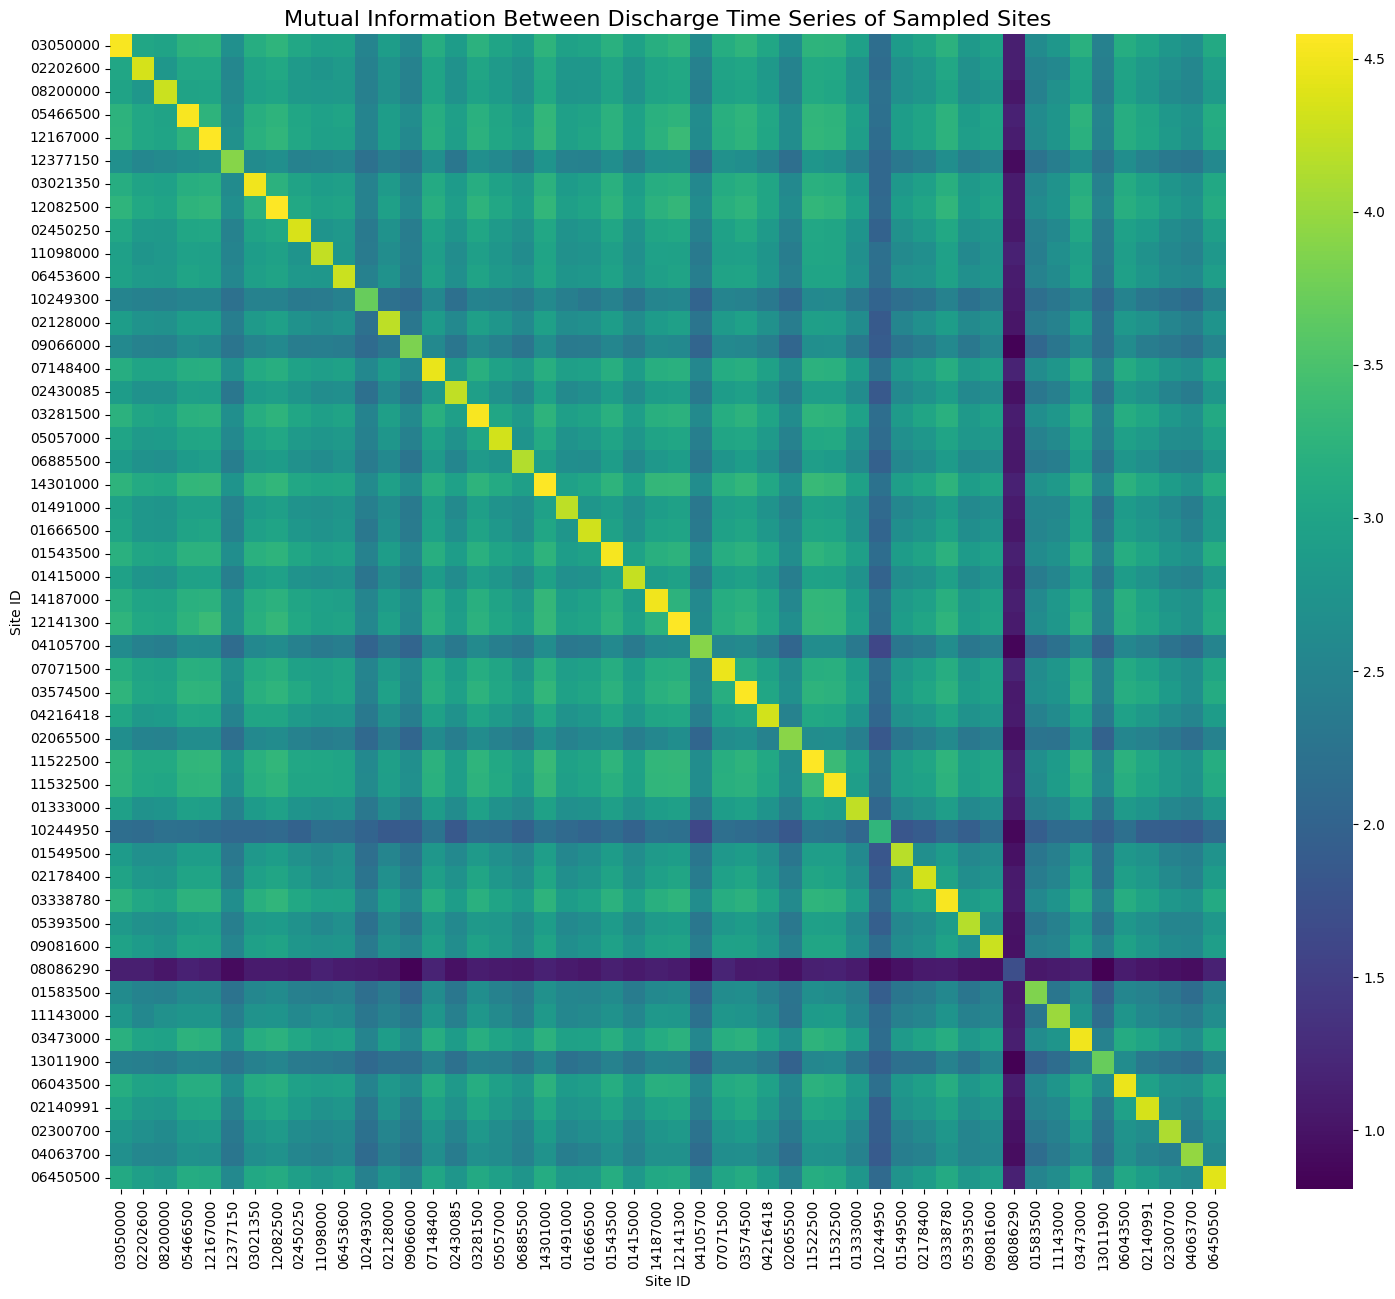

In [15]:

N_BINS = 100 # This is a key parameter. More bins capture more detail but require more data.
start_date = "2001-01-01"
end_date = "2002-01-01" 
random_sites = random.sample(list(discharge_pivot.columns), 50)

print(f"Discretizing data into {N_BINS} bins using quantiles...")
discretized_df = discharge_pivot.loc[start_date:end_date, random_sites].apply(
    lambda x: pd.qcut(x, q=N_BINS, labels=False, duplicates='drop')
).fillna(0)
print("Discretization complete.")
print("\nSample of discretized data:")
print(discretized_df.head())

sites = discretized_df.columns
mi_matrix = pd.DataFrame(np.zeros((len(sites), len(sites))), index=sites, columns=sites)

print("\nCalculating pairwise mutual information matrix...")
# Use itertools.combinations for an efficient way to get all unique pairs
for site1, site2 in tqdm(list(itertools.combinations(sites, 2))):
    # Calculate the MI score
    score = mutual_info_score(discretized_df[site1], discretized_df[site2])
    # The matrix is symmetric, so we fill both entries
    mi_matrix.loc[site1, site2] = score
    mi_matrix.loc[site2, site1] = score

# The MI of a variable with itself is its entropy. We can calculate this for the diagonal.
for site in sites:
    mi_matrix.loc[site, site] = mutual_info_score(discretized_df[site], discretized_df[site])

print("Mutual information calculation complete.")
print("\nMutual Information Matrix (sample):")
print(mi_matrix.iloc[:5, :5])


# In[5]:
# --- Step 4: Visualize the Mutual Information Matrix ---
print("\nVisualizing the results as a heatmap...")

plt.figure(figsize=(18, 15))
sns.heatmap(
    mi_matrix,
    cmap='viridis',
    annot=False # Annotating is not feasible for this many sites
)
plt.title('Mutual Information Between Discharge Time Series of Sampled Sites', fontsize=16)
plt.xlabel('Site ID')
plt.ylabel('Site ID')
plt.show()


Calculating Pearson correlation matrix...
Pearson correlation calculation complete.

Pearson Correlation Matrix (sample):
siteCode  01013500  01022500  01030500  01031500  01047000
siteCode                                                  
01013500  1.000000  0.345663  0.695480  0.455746  0.426188
01022500  0.345663  1.000000  0.669559  0.696941  0.642012
01030500  0.695480  0.669559  1.000000  0.675924  0.595880
01031500  0.455746  0.696941  0.675924  1.000000  0.915864
01047000  0.426188  0.642012  0.595880  0.915864  1.000000


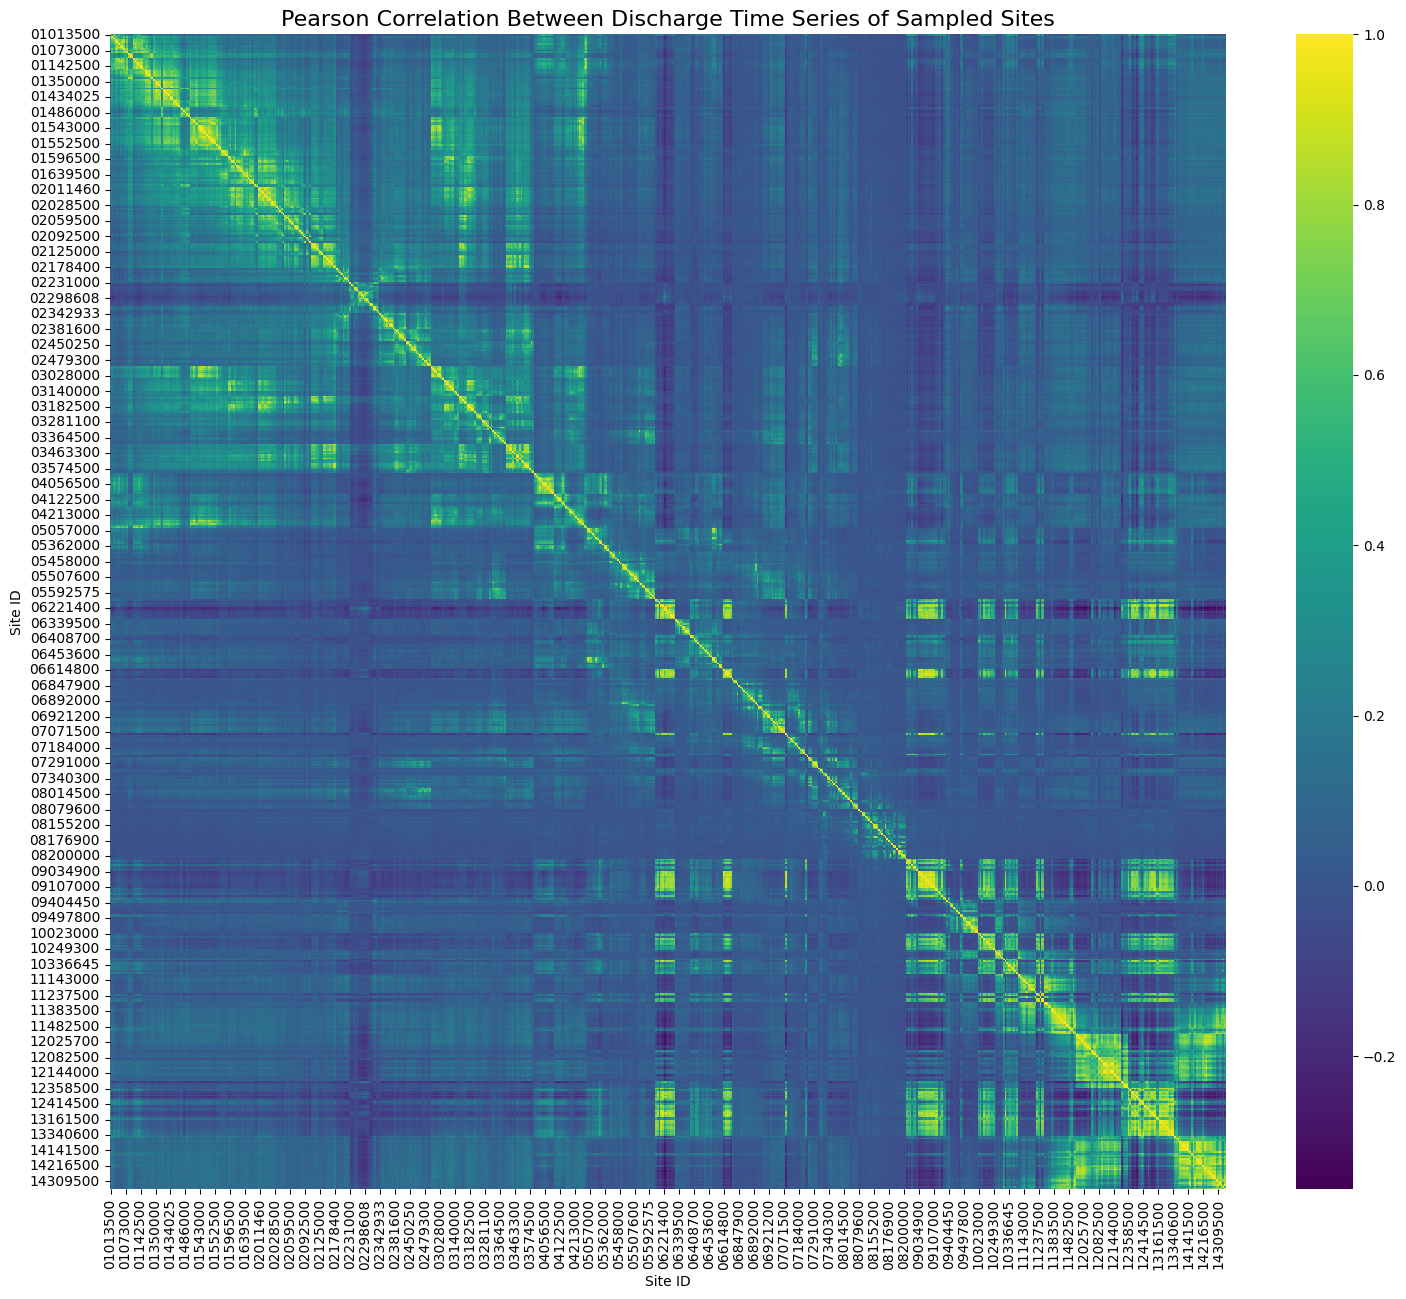

<Figure size 640x480 with 0 Axes>

In [9]:
EDA_OUTPUT_DIR = Path("eda_plots")
PROCESSED_DATA_DIR = Path("processed_data")
ADJ_MATRIX_PATH = "processed_camels_discharge_only/new_adjacency_matrix.pkl"
BASIN_CHARS_PATH = Path("data_camels/basin_characteristics.csv") # Used for getting site IDs

all_sites = pd.read_csv(BASIN_CHARS_PATH, dtype={'site_no': str})['site_no'].astype(str).tolist()[:10]

print("\nCalculating Pearson correlation matrix...")
pearson_corr_matrix = discharge_pivot[all_sites].corr(method='pearson')
print("Pearson correlation calculation complete.")
print("\nPearson Correlation Matrix (sample):")
print(pearson_corr_matrix.iloc[:5, :5])

# Visualize the Pearson correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(
    pearson_corr_matrix,
    cmap='viridis',
    annot=False
)
plt.title('Pearson Correlation Between Discharge Time Series of Sampled Sites', fontsize=16)
plt.xlabel('Site ID')
plt.ylabel('Site ID')
plt.show()

# plt.savefig(EDA_OUTPUT_DIR / "camels_pearson_correlation_matrix.png", bbox_inches='tight')


Calculating Spearman correlation matrix...
Spearman correlation calculation complete.

Spearman Correlation Matrix (sample):
siteCode  01013500  01022500  01030500  01031500  01047000
siteCode                                                  
01013500  1.000000  0.549998  0.752268  0.678998  0.651654
01022500  0.549998  1.000000  0.824502  0.838601  0.789996
01030500  0.752268  0.824502  1.000000  0.867641  0.797001
01031500  0.678998  0.838601  0.867641  1.000000  0.919135
01047000  0.651654  0.789996  0.797001  0.919135  1.000000


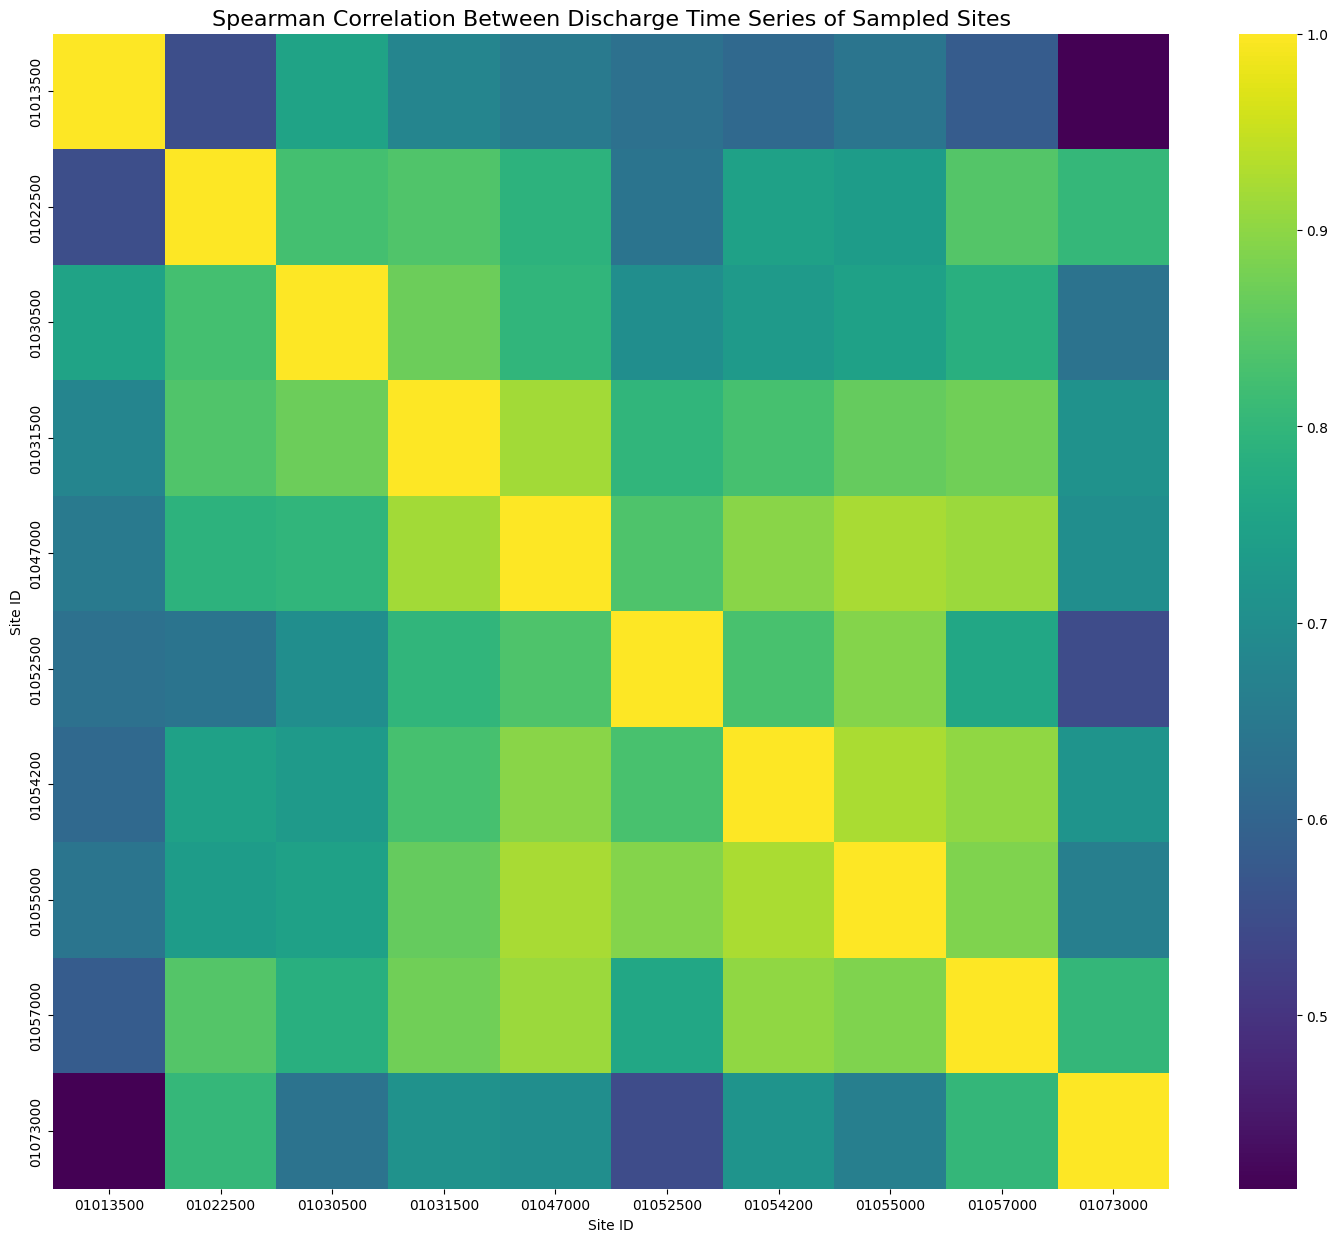

In [12]:

# In[4]:
# --- Step 3: Calculate Spearman Correlation Matrix ---
# Spearman correlation measures the monotonic relationship (rank-based).
# It's often more robust for non-linear relationships, which are common in hydrology.
print("\nCalculating Spearman correlation matrix...")
spearman_corr_matrix = discharge_pivot[all_sites].corr(method='spearman')

print("Spearman correlation calculation complete.")
print("\nSpearman Correlation Matrix (sample):")
print(spearman_corr_matrix.iloc[:5, :5])

# Visualize the Spearman correlation matrix
plt.figure(figsize=(18, 15))
sns.heatmap(
    spearman_corr_matrix,
    cmap='viridis',
    annot=False
)
plt.title('Spearman Correlation Between Discharge Time Series of Sampled Sites', fontsize=16)
plt.xlabel('Site ID')
plt.ylabel('Site ID')
plt.show()
# plt.savefig(EDA_OUTPUT_DIR / "camels_spearman_correlation_matrix.png", bbox_inches='tight')


Adjacency matrix loaded successfully with shape: (671, 671)

Plotting the full adjacency matrix to show overall graph structure...
[[0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149031
  0.00149031 0.00149031 0.00149031 0.00149031]
 [0.00149031 0.00149031 0.00149031 0.00149031 0.00149031 0.00149

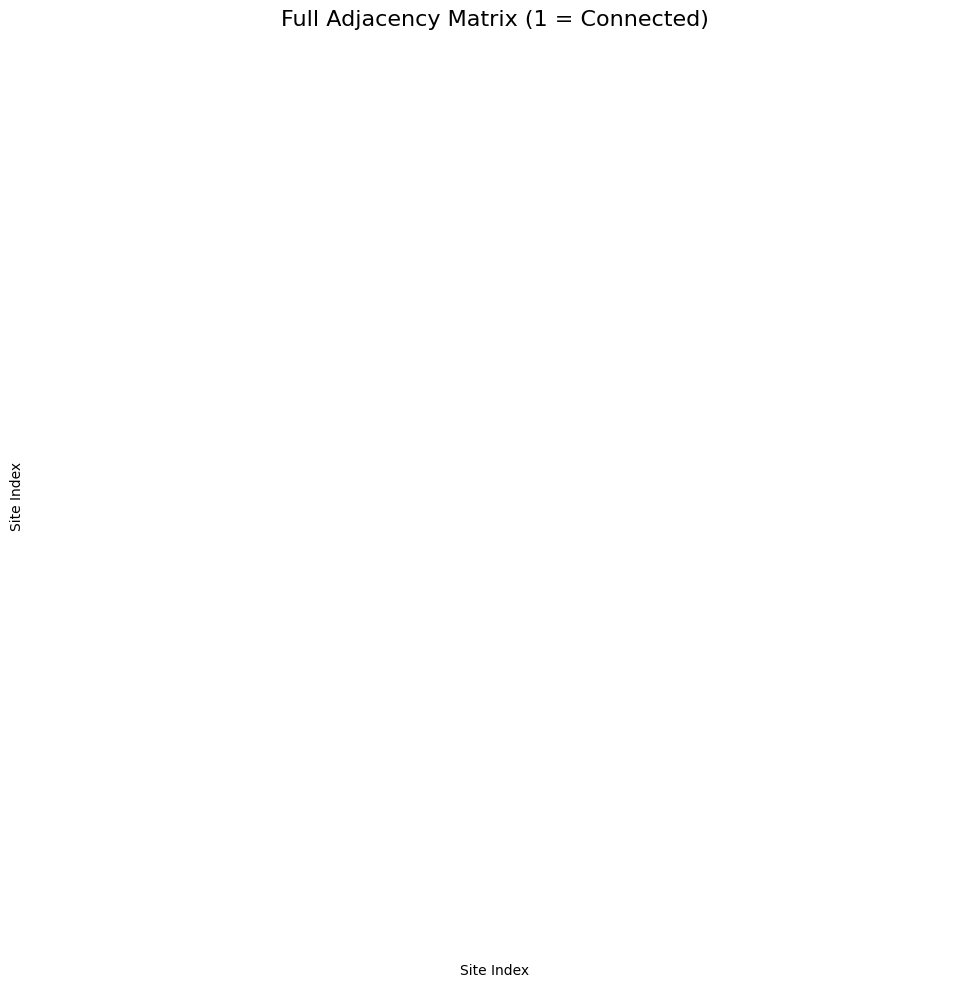

In [14]:
import pickle

PROCESSED_DATA_DIR = Path("processed_data")
ADJ_MATRIX_PATH = "processed_camels_discharge_only/new_adjacency_matrix.pkl"
BASIN_CHARS_PATH = Path("data_camels/basin_characteristics.csv") # Used for getting site IDs

with open(ADJ_MATRIX_PATH, 'rb') as f:
        adj_matrix = pickle.load(f)
    
all_sites = pd.read_csv(BASIN_CHARS_PATH, dtype = {'site_no': str})['site_no'].astype(str).tolist()[:10]
site_labels = all_sites

print(f"Adjacency matrix loaded successfully with shape: {adj_matrix.shape}")
print("\nPlotting the full adjacency matrix to show overall graph structure...")

print(adj_matrix[:10,:10])
plt.figure(figsize=(12, 12))
sns.heatmap(
    adj_matrix, # Display only the first 10 rows and columns for clarity
    cmap='gray_r', # Use a reverse grayscale map (1=black, 0=white)
    cbar=False,    # No color bar needed for a binary matrix
    xticklabels=False,
    yticklabels=False,
)
plt.title('Full Adjacency Matrix (1 = Connected)', fontsize=16)
plt.xlabel('Site Index')
plt.ylabel('Site Index')
plt.show()
# plt.savefig(EDA_OUTPUT_DIR / "camels_adj_matrix.png", bbox_inches='tight')


In [6]:
discharge_pivot.head()

siteCode,01013500,01022500,01030500,01031500,01047000,01052500,01054200,01055000,01057000,01073000,...,14303200,14305500,14306340,14306500,14308990,14309500,14316700,14325000,14362250,14400000
dateTime,,,,,,,,,,,,,,,,,,,,,
1980-01-01,655.0,395.0,2600.0,170.0,260.0,165.0,100.0,77.0,59.0,13.0,...,NaN,3190.0,NaN,3120.0,NaN,1200.0,836.0,2760.0,NaN,9640.0
1980-01-02,640.0,350.0,2260.0,140.0,225.0,150.0,98.0,72.0,51.0,12.0,...,NaN,2770.0,NaN,2590.0,NaN,786.0,848.0,1960.0,NaN,5940.0
1980-01-03,625.0,310.0,1940.0,120.0,200.0,140.0,95.0,70.0,44.0,10.0,...,NaN,2400.0,NaN,2330.0,NaN,578.0,735.0,1430.0,NaN,4100.0
1980-01-04,620.0,275.0,1650.0,105.0,175.0,135.0,94.0,67.0,38.0,9.0,...,NaN,2800.0,NaN,2110.0,NaN,449.0,708.0,1130.0,NaN,3110.0
1980-01-05,605.0,250.0,1460.0,94.0,160.0,130.0,90.0,65.0,35.0,8.5,...,NaN,2510.0,NaN,3720.0,NaN,528.0,2210.0,1390.0,NaN,3200.0


In [5]:
discharge_pivot.shape

(12784, 671)

In [ ]:
from scipy.optimize import linprog
import time

def wasserstein_distance(p, q, D):
    """
    Calculates the Wasserstein distance (Earth Mover's Distance) between
    two probability distributions p and q, given a cost matrix D.
    This is solved as a linear programming problem.
    """
    # Create the equality constraint matrix A_eq
    A_eq = []
    # Constraint for p: sum of transported mass from each source i must equal p[i]
    for i in range(len(p)):
        A = np.zeros_like(D)
        A[i, :] = 1
        A_eq.append(A.flatten())
    # Constraint for q: sum of transported mass to each destination j must equal q[j]
    for i in range(len(q)):
        A = np.zeros_like(D)
        A[:, i] = 1
        A_eq.append(A.flatten())

    A_eq = np.array(A_eq)
    # Combine the probability distributions for the equality constraints
    b_eq = np.concatenate([p, q])
    
    # Flatten the cost matrix for the linear programming solver
    D_flat = D.flatten()

    # Solve the linear programming problem
    # We can drop one constraint as the total mass is conserved (sum(p) == sum(q) == 1)
    start = time.time()
    result = linprog(c=D_flat, A_eq=A_eq[:-1], b_eq=b_eq[:-1])
    print("lin_prog time: ", time.time() - start)
    
    return result.fun

def spatial_temporal_aware_distance(x, y):
    """
    Calculates the Spatial-Temporal Aware Distance (STAD) between two
    time-series x and y.
    """
    start = time.time()
    # Ensure inputs are numpy arrays
    x, y = np.array(x), np.array(y)

    # Step 1: Create probability distributions (p, q)
    # Calculate the L2 norm for each day's vector to represent daily volume
    x_norm = (x**2).sum(axis=1, keepdims=True)**0.5
    y_norm = (y**2).sum(axis=1, keepdims=True)**0.5
    
    print("x_norm time: ", time.time() - start)
    start = time.time()
    x_norm = np.nan_to_num(x_norm, nan=0.0)
    y_norm = np.nan_to_num(y_norm, nan=0.0)
    print("fill nan time: ", time.time() - start)
    start = time.time()

    # Handle potential division by zero if a day has zero flow
    x_norm[x_norm == 0] = 1e-4
    y_norm[y_norm == 0] = 1e-4

    # Normalize daily volumes to get probability distributions
    p = x_norm.flatten() / x_norm.sum()
    q = y_norm.flatten() / y_norm.sum()

    # Step 2: Create the cost matrix (D) using cosine distance
    # Normalize each daily vector before calculating cosine similarity
    x_normalized_daily = x / x_norm
    y_normalized_daily = y / y_norm
    D = 1 - np.dot(x_normalized_daily, y_normalized_daily.T)
    # check for nan and inf in D
    if np.isnan(D).any() or np.isinf(D).any():
        # print("Warning: Cost matrix D contains NaN or Inf values. Replacing with zeros.")
        D = np.nan_to_num(D, nan=0.0, posinf=0.0, neginf=0.0)
    # Step 3: Compute Wasserstein Distance
    return wasserstein_distance(p, q, D)
BASIN_CHARS_PATH = Path("data_camels/basin_characteristics.csv") # Used for getting site IDs
all_sites = pd.read_csv(BASIN_CHARS_PATH, dtype={'site_no': str})['site_no'].astype(str).tolist()
DATA_DIR = Path("./data_camels")
DISCHARGE_PATH = DATA_DIR / "usgs_discharge.csv"

discharge_df = pd.read_csv(DISCHARGE_PATH, parse_dates=['dateTime'], dtype={'siteCode': str})
discharge_pivot = discharge_df.pivot(index='dateTime', columns='siteCode', values='value')
discharge_pivot = discharge_pivot[all_sites]  # Ensure we only use the sites we have characteristics for

TIMESTEPS_PER_SEQUENCE = 30 # This is 'dr' from the paper's methodology
SPARSITY = 0.05             # Keep edges for the top 5% most similar nodes for each node

# Get data dimensions
total_timesteps, num_nodes = discharge_pivot.shape
num_sequences = total_timesteps // TIMESTEPS_PER_SEQUENCE
truncated_timesteps = num_sequences * TIMESTEPS_PER_SEQUENCE
data_truncated = discharge_pivot.iloc[:truncated_timesteps].values

data_reshaped = data_truncated.reshape(num_sequences, TIMESTEPS_PER_SEQUENCE, num_nodes)
print(f"Original data shape: {discharge_pivot.shape}")
print(f"Reshaped data for STAD calculation: {data_reshaped.shape}")
print(f"-> {data_reshaped.shape[0]} sequences of {data_reshaped.shape[1]} timesteps for {data_reshaped.shape[2]} nodes.")
similarity_matrix = np.zeros((num_nodes, num_nodes))
print(f"Calculating STAD similarity matrix for {num_nodes} nodes...")
start_time = time.time()

for i in range(num_nodes):
    print(f"\rProcessing node {i + 1}/{num_nodes}", flush=True)
    for j in range(i, num_nodes): # Use symmetry to reduce calculations
        if i == j:
            similarity_matrix[i, j] = 1.0
            continue
        
        # Extract data for node i and node j
        node_i_data = data_reshaped[:, :, i]
        node_j_data = data_reshaped[:, :, j]
        
        # Calculate STAD and convert to similarity
        stad = spatial_temporal_aware_distance(node_i_data, node_j_data)
        similarity = 1 - stad
        
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity # Symmetric matrix
    

end_time = time.time()
print(f"\nSimilarity matrix calculation finished in {end_time - start_time:.2f} seconds.")
print("-" * 50)

adj_matrix = np.zeros((num_nodes, num_nodes))
top_k = int(num_nodes * SPARSITY)

print(f"Generating sparse adjacency matrix with sparsity={SPARSITY} (top {top_k} connections per node)...")

for i in range(num_nodes):
    # Get the indices of the top_k most similar nodes for node i
    # We use .argsort() which sorts in ascending order, so we take from the end
    top_k_indices = similarity_matrix[i, :].argsort()[-top_k:]
    
    # Set the corresponding entries in the adjacency matrix to 1
    adj_matrix[i, top_k_indices] = 1

print("Adjacency matrix generated.")
print(f"Final Adjacency Matrix Shape: {adj_matrix.shape}")
print(f"Sparsity of adjacency matrix: {adj_matrix.sum() / (num_nodes * num_nodes):.4f}")

# Display the first 5x5 part of the matrix as an example
print("\nAdjacency Matrix (first 5x5):")
print(adj_matrix[:5, :5])


Original data shape: (12784, 671)
Reshaped data for STAD calculation: (426, 30, 671)
-> 426 sequences of 30 timesteps for 671 nodes.
Calculating STAD similarity matrix for 671 nodes...
Processing node 1/671
x_norm time:  0.0008018016815185547
fill nan time:  0.0007610321044921875
lin_prog time:  7.49299693107605
x_norm time:  0.0003516674041748047
fill nan time:  0.0001277923583984375
lin_prog time:  7.102030515670776
x_norm time:  0.0007598400115966797
fill nan time:  0.00024390220642089844
lin_prog time:  8.992124557495117
x_norm time:  0.00034236907958984375
fill nan time:  9.655952453613281e-05
lin_prog time:  10.931425333023071
x_norm time:  0.0003695487976074219
fill nan time:  0.00010156631469726562
lin_prog time:  10.9219069480896
x_norm time:  0.0007610321044921875
fill nan time:  0.00013637542724609375
lin_prog time:  7.0680458545684814
x_norm time:  0.00043320655822753906
fill nan time:  0.0002262592315673828
lin_prog time:  7.06403112411499
x_norm time:  0.00035524368286132